In [1]:
import sys
from pathlib import Path
import time
import json
import math

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset


def find_project_root(marker="data/imagenet100"):
    current = Path.cwd()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not find project root containing {marker}")

PROJECT_ROOT = find_project_root()
EMBEDDINGS_DIR = PROJECT_ROOT / "data" / "embeddings"
CHECKPOINTS_DIR = PROJECT_ROOT / "checkpoints"
RESULTS_DIR = PROJECT_ROOT / "results"
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

Device: mps


In [2]:
def load_embeddings(split):
    path = EMBEDDINGS_DIR / f"{split}_embeddings.pt"
    data = torch.load(path, weights_only=True)
    return data["features"], data["labels"]


train_features, train_labels = load_embeddings("train")
val_features, val_labels = load_embeddings("val")
heldout_features, heldout_labels = load_embeddings("heldout")

train_dataset = TensorDataset(train_features, train_labels)
val_dataset = TensorDataset(val_features, val_labels)
heldout_dataset = TensorDataset(heldout_features, heldout_labels)

BATCH_SIZE = 512

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
heldout_loader = DataLoader(heldout_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_features):,} | Val: {len(val_features):,} | Heldout: {len(heldout_features):,}")

Train: 117,000 | Val: 13,000 | Heldout: 5,000


In [3]:
class TverskyProjectionLayer(nn.Module):
    """
    Tversky projection layer from Doumbouya et al. (2025).
    
    Computes logit_i = ω·f(X ∩ Y_i) - ε·f(X \ Y_i) - ϑ·f(Y_i \ X), where:
        - X = feature memberships of input x (positive dot products with Φ)
        - Y_i = feature memberships of prototype Π_i
        - Intersection uses 'product' reduction (paper's best XOR config)
        - Difference uses 'subtractmatch' (paper's best XOR config)
        - ε, ϑ, ω are learnable scalar weights
    
    Args:
        embed_dim: input feature dimensionality (2048)
        n_classes: number of output classes (100)
        n_features: feature bank size |Φ| (default 224, matching NABirds)
    """
    def __init__(self, embed_dim=2048, n_classes=100, n_features=224):
        super().__init__()
        self.embed_dim = embed_dim
        self.n_classes = n_classes
        self.n_features = n_features
        
        # Feature bank: |Φ| feature vectors of dimension embed_dim
        # Uniform initialization (paper's best XOR finding)
        self.feature_bank = nn.Parameter(torch.empty(n_features, embed_dim))
        nn.init.uniform_(self.feature_bank, -0.1, 0.1)
        
        # Prototype bank: one prototype per class
        # Uniform initialization
        self.prototypes = nn.Parameter(torch.empty(n_classes, embed_dim))
        nn.init.uniform_(self.prototypes, -0.1, 0.1)
        
        # Tversky weights: ε, ϑ, ω as learnable positive scalars
        self.epsilon = nn.Parameter(torch.tensor(1.0))   # weight on x's distinctive features
        self.theta = nn.Parameter(torch.tensor(1.0))     # weight on prototype's distinctive features
        self.omega = nn.Parameter(torch.tensor(1.0))     # weight on common features
    
    def forward(self, x):
        # x: [B, embed_dim]
        # feature_bank: [F, embed_dim] where F = n_features
        # prototypes: [C, embed_dim] where C = n_classes
        
        B = x.size(0)
        F_n = self.n_features
        C = self.n_classes
        
        # Compute feature memberships (raw, before thresholding)
        # X[b, k] = x_b · f_k = "how much of feature k is in input b"
        X = x @ self.feature_bank.T              # [B, F]
        # Y[i, k] = Π_i · f_k = "how much of feature k is in prototype i"  
        Y = self.prototypes @ self.feature_bank.T # [C, F]
        
        # Active feature masks (positive membership)
        X_active = (X > 0).float()  # [B, F]
        Y_active = (Y > 0).float()  # [C, F]
        
        # Broadcast to [B, C, F] for pairwise computations
        X_bcf = X.unsqueeze(1).expand(B, C, F_n)              # [B, C, F]
        Y_bcf = Y.unsqueeze(0).expand(B, C, F_n)              # [B, C, F]
        X_act_bcf = X_active.unsqueeze(1).expand(B, C, F_n)   # [B, C, F]
        Y_act_bcf = Y_active.unsqueeze(0).expand(B, C, F_n)   # [B, C, F]
        
        # === Common features: f(X ∩ Y_i) with 'product' reduction ===
        # Active in both: mask is X_act * Y_act
        # Reduction: φ(X, Y) = X * Y (product)
        # Sum over features where both are active
        common_mask = X_act_bcf * Y_act_bcf                   # [B, C, F]
        common_per_feature = X_bcf * Y_bcf                    # [B, C, F]
        f_intersect = (common_per_feature * common_mask).sum(dim=2)  # [B, C]
        
        # === Distinctive features for x (X \ Y) with 'subtractmatch' ===
        # Part 1 (ignorematch): features in X but not Y
        only_X_mask = X_act_bcf * (1 - Y_act_bcf)             # [B, C, F]
        f_X_only = (X_bcf * only_X_mask).sum(dim=2)           # [B, C]
        
        # Part 2 (subtractmatch addition): features in both, but X > Y
        # Mask: both active AND X > Y
        both_active = X_act_bcf * Y_act_bcf                   # [B, C, F]
        X_greater = (X_bcf > Y_bcf).float()                   # [B, C, F]
        subtract_mask = both_active * X_greater               # [B, C, F]
        f_X_subtract = ((X_bcf - Y_bcf) * subtract_mask).sum(dim=2)  # [B, C]
        
        f_X_distinctive = f_X_only + f_X_subtract             # [B, C]
        
        # === Distinctive features for Y (Y \ X) with 'subtractmatch' ===
        # Symmetric to above with X and Y swapped
        only_Y_mask = Y_act_bcf * (1 - X_act_bcf)             # [B, C, F]
        f_Y_only = (Y_bcf * only_Y_mask).sum(dim=2)           # [B, C]
        
        Y_greater = (Y_bcf > X_bcf).float()                   # [B, C, F]
        subtract_mask_Y = both_active * Y_greater             # [B, C, F]
        f_Y_subtract = ((Y_bcf - X_bcf) * subtract_mask_Y).sum(dim=2)  # [B, C]
        
        f_Y_distinctive = f_Y_only + f_Y_subtract             # [B, C]
        
        # === Combine into Tversky similarity ===
        logits = self.omega * f_intersect - self.epsilon * f_X_distinctive - self.theta * f_Y_distinctive
        
        return logits


# Instantiate and inspect
N_FEATURES = 224
model = TverskyProjectionLayer(
    embed_dim=2048,
    n_classes=100,
    n_features=N_FEATURES,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: TverskyProjectionLayer")
print(f"|Φ| (feature bank size): {N_FEATURES}")
print(f"Total parameters: {n_params:,}")
print(f"Trainable parameters: {n_trainable:,}")
print(f"\nParameter breakdown:")
print(f"  Feature bank Φ: {model.feature_bank.shape} = {model.feature_bank.numel():,} params")
print(f"  Prototype bank Π: {model.prototypes.shape} = {model.prototypes.numel():,} params")
print(f"  Tversky weights ε, ϑ, ω: 3 params")

Model: TverskyProjectionLayer
|Φ| (feature bank size): 224
Total parameters: 663,555
Trainable parameters: 663,555

Parameter breakdown:
  Feature bank Φ: torch.Size([224, 2048]) = 458,752 params
  Prototype bank Π: torch.Size([100, 2048]) = 204,800 params
  Tversky weights ε, ϑ, ω: 3 params


In [4]:
features, labels = next(iter(train_loader))
features = features.to(device)
labels = labels.to(device)

logits = model(features)

print(f"Input shape:  {features.shape}")
print(f"Output shape: {logits.shape}")
print(f"Output dtype: {logits.dtype}")
print(f"Output stats: mean={logits.mean():.4f}, std={logits.std():.4f}")
print(f"Output range: [{logits.min():.4f}, {logits.max():.4f}]")
print(f"Random prediction accuracy: {(logits.argmax(dim=1) == labels).float().mean():.4f}")

# Check that ε, ϑ, ω initialized correctly
print(f"\nTversky weights at init:")
print(f"  ε (epsilon, weight on x distinctive): {model.epsilon.item():.4f}")
print(f"  ϑ (theta, weight on prototype distinctive): {model.theta.item():.4f}")
print(f"  ω (omega, weight on common): {model.omega.item():.4f}")

Input shape:  torch.Size([512, 2048])
Output shape: torch.Size([512, 100])
Output dtype: torch.float32
Output stats: mean=-29.2229, std=3.3119
Output range: [-45.6075, -18.9483]
Random prediction accuracy: 0.0195

Tversky weights at init:
  ε (epsilon, weight on x distinctive): 1.0000
  ϑ (theta, weight on prototype distinctive): 1.0000
  ω (omega, weight on common): 1.0000


In [6]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    
    for features, labels in loader:
        features = features.to(device)
        labels = labels.to(device)
        
        logits = model(features)
        loss = criterion(logits, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * features.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += features.size(0)
    
    return total_loss / total_samples, total_correct / total_samples


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    
    for features, labels in loader:
        features = features.to(device)
        labels = labels.to(device)
        
        logits = model(features)
        loss = criterion(logits, labels)
        
        total_loss += loss.item() * features.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += features.size(0)
    
    return total_loss / total_samples, total_correct / total_samples


@torch.no_grad()
def measure_tversky_diagnostics(model):
    """Track ε, ϑ, ω and norms during training."""
    return {
        "epsilon": model.epsilon.item(),
        "theta": model.theta.item(),
        "omega": model.omega.item(),
        "feature_bank_norm": model.feature_bank.norm().item(),
        "prototypes_norm": model.prototypes.norm().item(),
    }


def fit_tversky(model, train_loader, val_loader, optimizer, criterion, device, n_epochs):
    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": [],
        "epsilon": [], "theta": [], "omega": [],
        "feature_bank_norm": [], "prototypes_norm": [],
    }
    
    print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | "
          f"{'Val Loss':>9} | {'Val Acc':>8} | "
          f"{'ε':>6} | {'ϑ':>6} | {'ω':>6} | {'Time':>6}")
    print("-" * 100)
    
    for epoch in range(1, n_epochs + 1):
        start = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        diag = measure_tversky_diagnostics(model)
        elapsed = time.time() - start
        
        for k, v in diag.items():
            history[k].append(v)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        
        print(f"{epoch:>5} | {train_loss:>10.4f} | {train_acc:>8.2%} | "
              f"{val_loss:>9.4f} | {val_acc:>7.2%} | "
              f"{diag['epsilon']:>6.3f} | {diag['theta']:>6.3f} | {diag['omega']:>6.3f} | "
              f"{elapsed:>5.1f}s")
    
    return history


# Same hyperparameters as before
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
N_EPOCHS = 30
N_FEATURES = 224

# Fresh model
model = TverskyProjectionLayer(
    embed_dim=2048,
    n_classes=100,
    n_features=N_FEATURES,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

print(f"Training Tversky projection layer")
print(f"  |Φ| = {N_FEATURES}, intersection=product, difference=subtractmatch")
print(f"  {N_EPOCHS} epochs, lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY}\n")

history = fit_tversky(model, train_loader, val_loader, optimizer, criterion, device, n_epochs=N_EPOCHS)

print(f"\nFinal ε / ϑ / ω: {history['epsilon'][-1]:.3f} / {history['theta'][-1]:.3f} / {history['omega'][-1]:.3f}")
print(f"Best validation accuracy: {max(history['val_acc']):.4f} "
      f"(epoch {history['val_acc'].index(max(history['val_acc'])) + 1})")

Training Tversky projection layer
  |Φ| = 224, intersection=product, difference=subtractmatch
  30 epochs, lr=0.001, weight_decay=0.0001

Epoch | Train Loss | Train Acc |  Val Loss |  Val Acc |      ε |      ϑ |      ω |   Time
----------------------------------------------------------------------------------------------------
    1 |     0.8567 |   77.10% |    0.6498 |  81.68% |  0.898 |  0.914 |  0.914 |  19.6s
    2 |     0.4922 |   85.25% |    0.5665 |  83.38% |  0.819 |  0.849 |  0.834 |  19.1s
    3 |     0.3973 |   87.81% |    0.5424 |  84.38% |  0.782 |  0.821 |  0.788 |  18.8s
    4 |     0.3398 |   89.32% |    0.5421 |  84.57% |  0.780 |  0.821 |  0.764 |  19.1s
    5 |     0.2923 |   90.67% |    0.5392 |  85.16% |  0.816 |  0.850 |  0.777 |  17.8s
    6 |     0.2599 |   91.60% |    0.5632 |  84.40% |  0.855 |  0.885 |  0.781 |  19.1s
    7 |     0.2295 |   92.54% |    0.5537 |  84.86% |  0.913 |  0.928 |  0.799 |  19.2s
    8 |     0.2041 |   93.28% |    0.5900 |  84.16% |  

In [7]:
checkpoint_path = CHECKPOINTS_DIR / f"tversky_F{N_FEATURES}_30ep.pt"
torch.save({
    "model_state_dict": model.state_dict(),
    "history": history,
    "hyperparameters": {
        "embed_dim": 2048,
        "n_classes": 100,
        "n_features": N_FEATURES,
        "intersection_reduction": "product",
        "difference_reduction": "subtractmatch",
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "n_epochs": N_EPOCHS,
        "batch_size": BATCH_SIZE,
        "optimizer": "Adam",
    },
    "final_metrics": {
        "train_loss": history["train_loss"][-1],
        "train_acc": history["train_acc"][-1],
        "val_loss": history["val_loss"][-1],
        "val_acc": history["val_acc"][-1],
        "best_val_acc": max(history["val_acc"]),
        "best_val_epoch": history["val_acc"].index(max(history["val_acc"])) + 1,
        "final_epsilon": history["epsilon"][-1],
        "final_theta": history["theta"][-1],
        "final_omega": history["omega"][-1],
    },
}, checkpoint_path)

print(f"Saved to {checkpoint_path}")

Saved to /Users/ayushkumarsingh/ABNS-Project/tversky-asymmetric/checkpoints/tversky_F224_30ep.pt


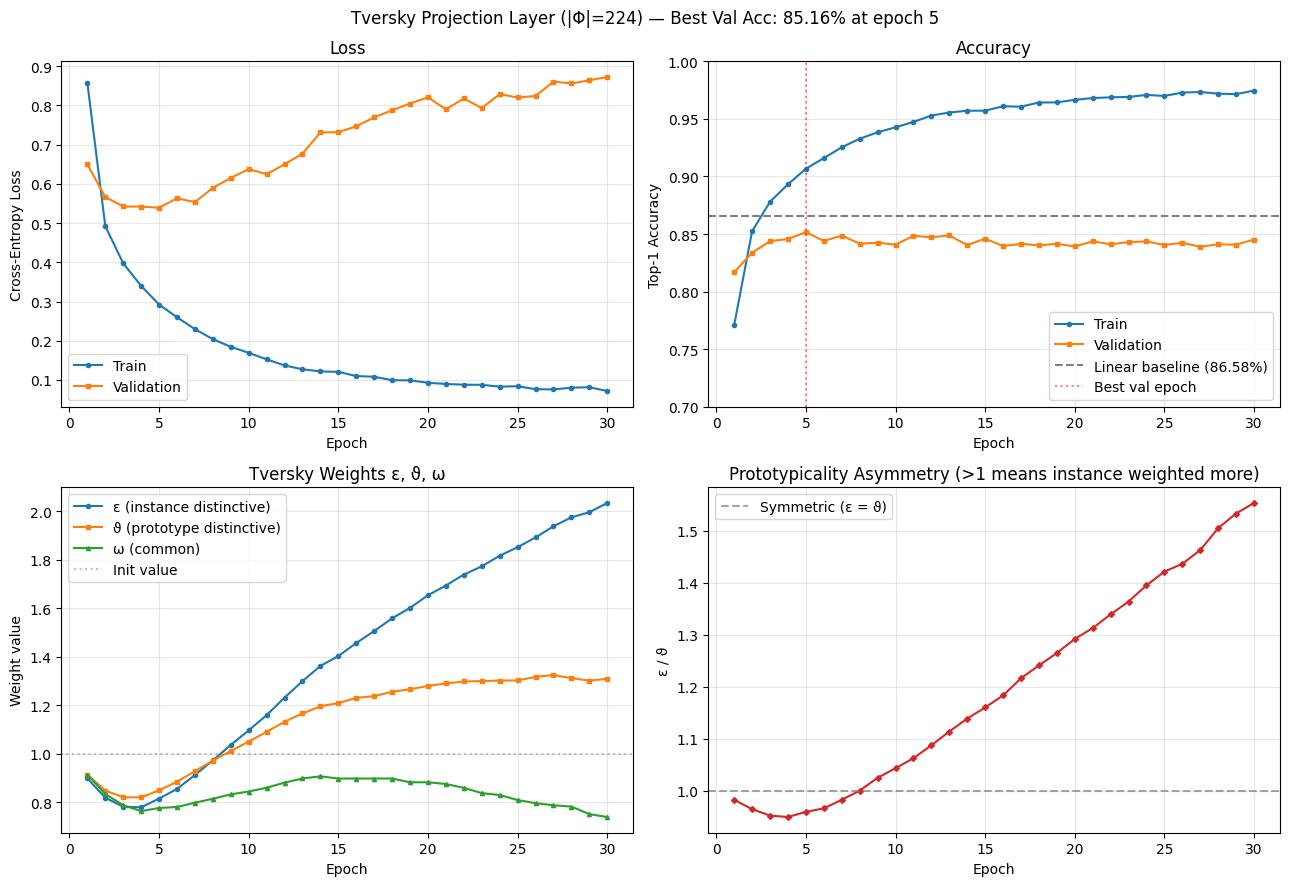

Saved plot to /Users/ayushkumarsingh/ABNS-Project/tversky-asymmetric/results/tversky_F224_30ep_curves.png


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

epochs = range(1, len(history["train_loss"]) + 1)

# Top-left: loss curves — the overfitting will be visible here
axes[0, 0].plot(epochs, history["train_loss"], label="Train", marker="o", markersize=3)
axes[0, 0].plot(epochs, history["val_loss"], label="Validation", marker="s", markersize=3)
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Cross-Entropy Loss")
axes[0, 0].set_title("Loss")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Top-right: accuracy
axes[0, 1].plot(epochs, history["train_acc"], label="Train", marker="o", markersize=3)
axes[0, 1].plot(epochs, history["val_acc"], label="Validation", marker="s", markersize=3)
axes[0, 1].axhline(0.8658, color="gray", linestyle="--", label="Linear baseline (86.58%)")
axes[0, 1].axvline(history["val_acc"].index(max(history["val_acc"])) + 1,
                    color="red", linestyle=":", alpha=0.5, label="Best val epoch")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Top-1 Accuracy")
axes[0, 1].set_title("Accuracy")
axes[0, 1].set_ylim(0.7, 1.0)
axes[0, 1].legend(loc="lower right")
axes[0, 1].grid(True, alpha=0.3)

# Bottom-left: Tversky weights evolution
axes[1, 0].plot(epochs, history["epsilon"], label="ε (instance distinctive)", marker="o", markersize=3)
axes[1, 0].plot(epochs, history["theta"], label="ϑ (prototype distinctive)", marker="s", markersize=3)
axes[1, 0].plot(epochs, history["omega"], label="ω (common)", marker="^", markersize=3)
axes[1, 0].axhline(1.0, color="gray", linestyle=":", alpha=0.5, label="Init value")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Weight value")
axes[1, 0].set_title("Tversky Weights ε, ϑ, ω")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Bottom-right: ε / ϑ ratio — the prototypicality asymmetry
ratio_eps_theta = [e / t for e, t in zip(history["epsilon"], history["theta"])]
axes[1, 1].plot(epochs, ratio_eps_theta, marker="D", markersize=3, color="C3")
axes[1, 1].axhline(1.0, color="gray", linestyle="--", alpha=0.7, label="Symmetric (ε = ϑ)")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("ε / ϑ")
axes[1, 1].set_title("Prototypicality Asymmetry (>1 means instance weighted more)")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f"Tversky Projection Layer (|Φ|=224) — "
             f"Best Val Acc: {max(history['val_acc']):.2%} at epoch {history['val_acc'].index(max(history['val_acc'])) + 1}",
             fontsize=12)
plt.tight_layout()

plot_path = RESULTS_DIR / f"tversky_F{N_FEATURES}_30ep_curves.png"
plt.savefig(plot_path, dpi=120, bbox_inches="tight")
plt.show()

print(f"Saved plot to {plot_path}")

In [9]:
# Early stopping

In [10]:
# Re-run Tversky with shorter training to capture pre-overfitting accuracy
N_EPOCHS_EARLY = 10

# Fresh model — same architecture
model_early = TverskyProjectionLayer(
    embed_dim=2048,
    n_classes=100,
    n_features=N_FEATURES,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_early.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

print(f"Tversky early-stopping run ({N_EPOCHS_EARLY} epochs)\n")
history_early = fit_tversky(model_early, train_loader, val_loader, optimizer, criterion, device, n_epochs=N_EPOCHS_EARLY)

best_epoch = history_early["val_acc"].index(max(history_early["val_acc"])) + 1
print(f"\nBest val acc (early-stopped): {max(history_early['val_acc']):.4f} (epoch {best_epoch})")
print(f"Final ε / ϑ / ω: {history_early['epsilon'][-1]:.3f} / "
      f"{history_early['theta'][-1]:.3f} / {history_early['omega'][-1]:.3f}")

Tversky early-stopping run (10 epochs)

Epoch | Train Loss | Train Acc |  Val Loss |  Val Acc |      ε |      ϑ |      ω |   Time
----------------------------------------------------------------------------------------------------
    1 |     0.8533 |   77.16% |    0.6506 |  80.90% |  0.894 |  0.923 |  0.913 |  19.1s
    2 |     0.4912 |   85.34% |    0.5751 |  83.12% |  0.809 |  0.861 |  0.824 |  19.1s
    3 |     0.3967 |   87.81% |    0.5340 |  84.65% |  0.773 |  0.834 |  0.779 |  18.5s
    4 |     0.3346 |   89.57% |    0.5221 |  85.14% |  0.785 |  0.845 |  0.772 |  19.1s
    5 |     0.2925 |   90.76% |    0.5311 |  85.06% |  0.812 |  0.862 |  0.767 |  19.2s
    6 |     0.2531 |   91.96% |    0.5558 |  84.89% |  0.870 |  0.900 |  0.790 |  19.1s
    7 |     0.2274 |   92.52% |    0.5693 |  84.95% |  0.930 |  0.938 |  0.806 |  19.1s
    8 |     0.2018 |   93.35% |    0.6004 |  84.89% |  0.992 |  0.977 |  0.824 |  19.2s
    9 |     0.1837 |   93.90% |    0.6106 |  84.74% |  1.051 |  1

In [11]:
checkpoint_path = CHECKPOINTS_DIR / f"tversky_F{N_FEATURES}_10ep.pt"
torch.save({
    "model_state_dict": model_early.state_dict(),
    "history": history_early,
    "hyperparameters": {
        "embed_dim": 2048,
        "n_classes": 100,
        "n_features": N_FEATURES,
        "intersection_reduction": "product",
        "difference_reduction": "subtractmatch",
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "n_epochs": N_EPOCHS_EARLY,
        "batch_size": BATCH_SIZE,
        "optimizer": "Adam",
    },
    "final_metrics": {
        "best_val_acc": max(history_early["val_acc"]),
        "best_val_epoch": history_early["val_acc"].index(max(history_early["val_acc"])) + 1,
        "final_epsilon": history_early["epsilon"][-1],
        "final_theta": history_early["theta"][-1],
        "final_omega": history_early["omega"][-1],
    },
}, checkpoint_path)

print(f"Saved to {checkpoint_path}")

Saved to /Users/ayushkumarsingh/ABNS-Project/tversky-asymmetric/checkpoints/tversky_F224_10ep.pt
